# GAN Variants and Modern Practice

The vanilla GAN objective is elegant, but its optimization signal can be fragile. The discriminator can become too sharp, the generator can receive weak gradients, and the game can fail to cover the full data distribution. GAN variants are best understood as targeted modifications of this adversarial system.

Three modifications are especially central. `WGAN-GP` changes the geometry of the critic signal. **Spectral normalization** constrains the discriminator function class. **Conditional GANs** change the generation task from unconditional sampling to controlled sampling. Intuitively, these correspond to three different questions: *what should the critic measure*, *how strong should the critic be allowed to become*, and *how can the user control what is generated*.

Each variant below is presented as a modeling response to a failure mode of the vanilla GAN. The code keeps the `FashionMNIST` pipeline and generator scale comparable across variants so that differences are easier to interpret. FID/KID is computed in a shared final block so that real-data features are cached once and reused for all generators.

```{admonition} Three stabilization levers
:class: note

`WGAN-GP` changes the discrepancy. **Spectral normalization** constrains the discriminator. **Conditional GANs** change the modeled distribution from $p_{gt}(\boldsymbol{x})$ to $p_{gt}(\boldsymbol{x}|\boldsymbol{y})$.
```

## Shared Setup

We keep the dataset, generator backbone, and most of the optimizer conventions fixed whenever possible. That way, differences in behavior are easier to attribute to the variant itself rather than to unrelated changes in the pipeline.

In [2]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# DCGAN-style settings are still teachable but produce much better samples.
latent_dim = 128
base_channels = 64
batch_size = 128
lr = 2e-4
epochs = 60

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


def discriminator_loss(real_logits, fake_logits):
    # Mild one-sided label smoothing stabilizes the discriminator.
    real_targets = torch.full_like(real_logits, 0.9)
    fake_targets = torch.zeros_like(fake_logits)

    real_loss = F.binary_cross_entropy_with_logits(real_logits, real_targets)
    fake_loss = F.binary_cross_entropy_with_logits(fake_logits, fake_targets)
    return real_loss + fake_loss


def generator_loss(fake_logits):
    # Non-saturating loss: the generator wants fake samples judged as real.
    real_targets = torch.ones_like(fake_logits)
    return F.binary_cross_entropy_with_logits(fake_logits, real_targets)


## WGAN-GP

The main idea of `WGAN-GP` is to make the critic's feedback more geometric. In a vanilla GAN, the discriminator can quickly learn a nearly binary separation between real and fake images. Once this happens, the generator may only hear a very poor message: "fake." WGAN replaces this binary-style feedback with a critic that tries to assign scores according to how much generated probability mass must move to look like real data.

The practical mechanism is also important. The discriminator becomes a **critic**, the sigmoid interpretation disappears, the loss estimates a difference of critic expectations, and a **gradient penalty** encourages approximate 1-Lipschitz behavior. The critic is no longer answering "is this real?" It is learning a scalar landscape that should guide generated samples toward the real distribution.

## From the Vanilla GAN to Wasserstein Geometry

The most important conceptual shift in the GAN literature is the move from the Jensen-Shannon geometry of the original game to the **Wasserstein-1 distance**. Informally, Wasserstein distance asks how much work is needed to move probability mass from the generated distribution to the real distribution. This transport interpretation is useful for images because a bad generator is often not wrong in a binary way. Its samples may be far from the data manifold, but they can still be moved gradually toward it.

A useful mental image is to think of piles of sand. The generated distribution is one arrangement of sand, and the real distribution is another. The Wasserstein distance measures how expensive it is to reshape one pile into the other. This is different from asking only whether the two piles overlap. Even if they do not overlap, there is still a meaningful direction in which mass should move.

The Kantorovich-Rubinstein duality gives the form used in WGAN:

```{math}
W_1(p_{gt}, p_\theta)
=
\sup_{\|f\|_L \le 1}
\mathbb{E}_{\boldsymbol{x}\sim p_{gt}}[f(\boldsymbol{x})]
-
\mathbb{E}_{\boldsymbol{x}\sim p_\theta}[f(\boldsymbol{x})].
```

The discriminator is replaced by a **critic** $f_\psi$. It no longer outputs a probability that must lie in $[0,1]$. It outputs a real number. Real samples should receive larger scores than generated samples. The generator then tries to make generated samples receive larger critic scores.

The condition $\|f\|_L \le 1$ is the condition that makes the dual formula equal to the Wasserstein distance. If the critic is unconstrained, it can arbitrarily scale its outputs and the objective loses its meaning. The original WGAN enforced this condition with weight clipping, but clipping can reduce critic capacity and create poor optimization behavior. `WGAN-GP` replaces clipping with a penalty on gradient norms:

```{math}
\lambda
\mathbb{E}_{\hat{\boldsymbol{x}}}
\left[
\left(
\|\nabla_{\hat{\boldsymbol{x}}} f_\psi(\hat{\boldsymbol{x}})\|_2 - 1
\right)^2
\right],
```

where $\hat{\boldsymbol{x}}$ is sampled along straight lines between real and generated images. The motivation is simple: if the critic is supposed to be smooth enough to guide the generator, then its slope should be controlled in the region between fake and real samples.

```{figure} ../assets/images/WGAN-GP.png
:width: 66%
:align: center

With WGAN, the discrimiator allies with the generator, becoming more a *critic*, which helps the generator to improve over time.
```

### WGAN-GP Losses

Let

```{math}
\boldsymbol{x}_{fake}=G_\theta(\boldsymbol{z}),
\qquad
\hat{\boldsymbol{x}}
=
\alpha \boldsymbol{x}_{real}
+
(1-\alpha)\boldsymbol{x}_{fake},
\qquad
\alpha \sim \mathcal{U}(0,1).
```

The critic is trained to give **larger scores to real images** and **smaller scores to generated images**, while also satisfying the gradient penalty. Since the code minimizes losses, the critic loss is written as

```{math}
\mathcal{L}_{D}^{WGAN\text{-}GP}
=
\mathbb{E}_{\boldsymbol{z}\sim p(\boldsymbol{z})}
\left[
f_\psi(G_\theta(\boldsymbol{z}))
\right]
-
\mathbb{E}_{\boldsymbol{x}\sim p_{gt}}
\left[
f_\psi(\boldsymbol{x})
\right]
+
\lambda
\mathbb{E}_{\hat{\boldsymbol{x}}}
\left[
\left(
\|\nabla_{\hat{\boldsymbol{x}}} f_\psi(\hat{\boldsymbol{x}})\|_2 - 1
\right)^2
\right].
```

The first two terms estimate the negative Wasserstein critic objective. Minimizing them increases the gap between real scores and fake scores in the desired direction. The last term prevents the critic from creating an arbitrarily steep landscape.

The generator does not use binary cross-entropy. It simply tries to make generated samples receive large critic scores:

```{math}
\mathcal{L}_{G}^{WGAN}
=
-
\mathbb{E}_{\boldsymbol{z}\sim p(\boldsymbol{z})}
\left[
f_\psi(G_\theta(\boldsymbol{z}))
\right].
```

This is the loss implemented below: the critic minimizes `fake_score - real_score + gradient_penalty`, and the generator minimizes `-fake_score`.

A simple mental picture helps. Imagine that the true data are images of shoes and the generator initially produces amorphous grayscale blobs. Under the original adversarial objective, the discriminator may confidently separate the two distributions, leaving little useful gradient structure. Under the Wasserstein view, the critic is encouraged to estimate how far probability mass must move to turn the blobs into plausible shoes. That tends to produce a more graded training signal.

The implementation reflects this change directly. There is no binary cross-entropy in the critic update. Real samples should receive larger critic values than fake samples. The **gradient penalty** is computed on interpolated images because this is the region where the critic must guide the generator from generated samples toward real samples. In many implementations the critic is updated several times per generator update, because the generator needs the critic to be a reasonably accurate transport guide. If the critic is too weak, the generator receives a noisy direction. If the critic is too strong or poorly constrained, the generator may again receive unstable gradients.

The limitation is also worth stating. `WGAN-GP` usually improves stability, but it does not make GAN training automatic. The **gradient penalty** is computationally expensive because it requires differentiating the critic output with respect to the input image. The Lipschitz constraint is only approximated in sampled regions. **Mode collapse** can still occur, especially if the critic, generator, learning rates, or number of critic updates are poorly balanced. Its value is that it makes the geometry of the training signal more meaningful, not that it removes the adversarial nature of the problem.

```{admonition} Why the **gradient penalty** appears
:class: tip

The Wasserstein dual requires a **1-Lipschitz critic**. The **gradient penalty** keeps the critic from becoming an infinitely steep scoring function and makes its scores more useful as directions for the generator.
```

In [3]:
class WGANGenerator(nn.Module):
    def __init__(self, latent_dim=128, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4 * 7 * 7),
            nn.BatchNorm1d(base_channels * 4 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)

class WGANCritic(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(base_channels * 2 * 7 * 7, 1),
        )
    def forward(self, x):
        return self.net(x)


In [ ]:
def gradient_penalty(critic, real_images, fake_images, device):
    batch_n = real_images.size(0)
    alpha = torch.rand(batch_n, 1, 1, 1, device=device)
    interpolated = alpha * real_images + (1 - alpha) * fake_images
    interpolated.requires_grad_(True)

    critic_scores = critic(interpolated)
    grad_outputs = torch.ones_like(critic_scores)
    gradients = torch.autograd.grad(
        outputs=critic_scores,
        inputs=interpolated,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(batch_n, -1)
    return ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()


def wgan_critic_loss(critic, real_images, fake_images, gp_weight=10.0):
    real_score = critic(real_images).mean()
    fake_score = critic(fake_images).mean()
    gp = gradient_penalty(critic, real_images, fake_images, real_images.device)
    loss = fake_score - real_score + gp_weight * gp
    return loss, real_score, fake_score, gp


def wgan_generator_loss(critic, fake_images):
    return -critic(fake_images).mean()


In [5]:
wgan_G = WGANGenerator(latent_dim=latent_dim, base_channels=base_channels).to(device)
wgan_D = WGANCritic(base_channels=base_channels).to(device)
wgan_g_optimizer = torch.optim.Adam(wgan_G.parameters(), lr=lr, betas=(0.5, 0.999))
wgan_d_optimizer = torch.optim.Adam(wgan_D.parameters(), lr=lr, betas=(0.5, 0.999))
wgan_epochs = 50
critic_steps = 5
wgan_history = {"d_loss": [], "g_loss": []}

for epoch in tqdm(range(wgan_epochs), desc="WGAN-GP epochs"):
    d_running = 0.0
    g_running = 0.0
    for real_images, _ in tqdm(train_loader, desc=f"WGAN train ({critic_steps} critic steps)", leave=False):
        real_images = real_images.to(device)
        batch_n = real_images.size(0)
        batch_d_loss = 0.0

        for _ in range(critic_steps):
            z = torch.randn(batch_n, latent_dim, device=device)
            fake_images = wgan_G(z)
            wgan_d_optimizer.zero_grad()
            d_loss, _, _, _ = wgan_critic_loss(wgan_D, real_images, fake_images.detach(), gp_weight=10.0)
            d_loss.backward()
            wgan_d_optimizer.step()
            batch_d_loss += d_loss.item()

        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = wgan_G(z)
        wgan_g_optimizer.zero_grad()
        g_loss = wgan_generator_loss(wgan_D, fake_images)
        g_loss.backward()
        wgan_g_optimizer.step()
        d_running += batch_d_loss / critic_steps
        g_running += g_loss.item()
    wgan_history["d_loss"].append(d_running / len(train_loader))
    wgan_history["g_loss"].append(g_running / len(train_loader))
    print(
        f"Epoch {epoch + 1:02d} | "
        f"critic loss: {wgan_history['d_loss'][-1]:.4f} | "
        f"generator loss: {wgan_history['g_loss'][-1]:.4f}"
    )


WGAN-GP epochs:   0%|          | 0/50 [00:00<?, ?it/s]

WGAN train (5 critic steps):   0%|          | 0/469 [00:00<?, ?it/s]

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01 | critic loss: -5.3181 | generator loss: -14.6935


WGAN train (5 critic steps):   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 48 | critic loss: -0.5769 | generator loss: -3.4624


WGAN train (5 critic steps):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | critic loss: -0.5697 | generator loss: -2.9208


WGAN train (5 critic steps):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | critic loss: -0.5606 | generator loss: -4.0684


Because `WGAN-GP` is still an unconditional model, we can evaluate it with the same kinds of sample grids and latent interpolations used in the vanilla GAN setting. The main visual difference one hopes for is not “sharper than everything else,” but more stable improvement and less obvious collapse.

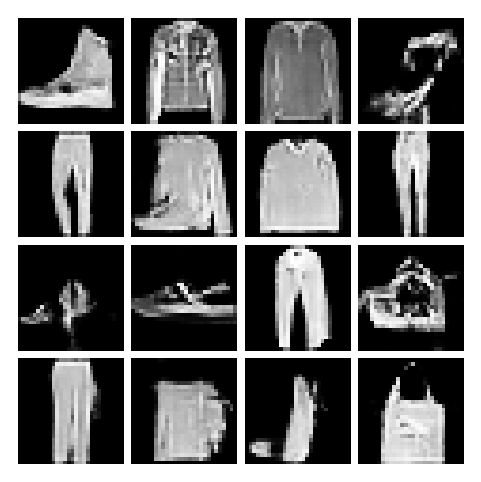

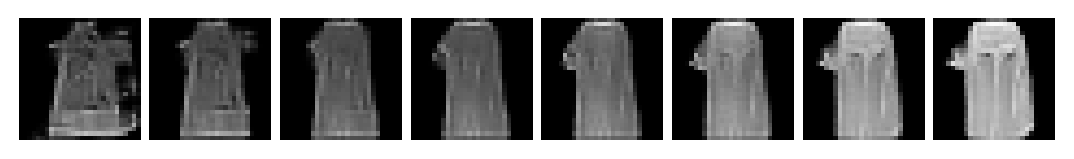

In [6]:
@torch.no_grad()
def show_gan_samples(generator, device, n=16):
    generator.eval()
    z = torch.randn(n, latent_dim, device=device)
    samples = 0.5 * (generator(z) + 1.0)
    image = utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.show()

@torch.no_grad()
def show_gan_interpolation(generator, device, steps=8):
    generator.eval()
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * z0 + alphas * z1
    samples = 0.5 * (generator(z) + 1.0)
    image = utils.make_grid(samples.cpu(), nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(image.permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.show()

show_gan_samples(wgan_G, device)
show_gan_interpolation(wgan_G, device)


## Spectral Normalization GAN

**Spectral normalization** leaves the outer adversarial game close to the original non-saturating GAN, but changes the discriminator itself. The intuition is direct: if the discriminator becomes too steep, tiny image changes can produce huge score changes, and the generator receives unstable feedback. Spectral normalization limits how much each layer can amplify its input.

This makes it a clean comparison point with `WGAN-GP`. WGAN-GP adds an input-**gradient penalty** to the loss. Spectral normalization constrains the **operator norm** of the discriminator layers. One method says "penalize bad slopes when they appear." The other says "build a discriminator that is less able to create extreme slopes in the first place." 

**Spectral normalization** is a different answer to the same broad question: how do we keep the critic from becoming too wild? For a linear layer with weight matrix $\boldsymbol{W}$, the spectral norm is the largest singular value,

```{math}
\sigma(\boldsymbol{W})
=
\sup_{\boldsymbol{h} \neq \boldsymbol{0}}
\frac{\|\boldsymbol{W}\boldsymbol{h}\|_2}{\|\boldsymbol{h}\|_2}.
```

This number measures the maximum factor by which the layer can stretch an input perturbation. If $\sigma(\boldsymbol{W})$ is large, the layer can strongly amplify small changes. Spectral normalization replaces $\boldsymbol{W}$ by

```{math}
\bar{\boldsymbol{W}}
=
\frac{\boldsymbol{W}}{\sigma(\boldsymbol{W})}.
```

In practice, $\sigma(\boldsymbol{W})$ is estimated with a small number of power-iteration steps during training. The result is not an exact global Lipschitz guarantee for the whole neural network, because nonlinearities, residual paths, convolutional structure, and composition all matter. Nevertheless, controlling the largest singular value of each layer strongly limits the discriminator's ability to create extremely steep decision surfaces.

```{figure} ../assets/images/SN-GAN.png
:width: 66%
:align: center

The Spectral Normalization makes the loss landscape smoother, reducing the *jumps* in model performance.
```

The limitation is that **spectral normalization** controls capacity rather than changing the divergence itself. It can make the discriminator smoother and more stable, but it does not turn the objective into a transport distance. This is why it is best understood as critic regularization rather than as a complete replacement for the GAN game.

```{admonition} **Spectral normalization**
:class: tip

**Spectral normalization** is like putting a speed limit on each discriminator layer: it does not change the destination of training, but it prevents the critic from reacting too violently to small input changes.
```

In [7]:
class SNDiscriminator(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(
                nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(
                nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.utils.spectral_norm(
                nn.Linear(base_channels * 2 * 7 * 7, 1)
            ),
        )

    def forward(self, x):
        return self.net(x)


sn_discriminator = SNDiscriminator(base_channels=base_channels).to(device)
sn_optimizer = torch.optim.Adam(sn_discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

In [8]:
sn_G = WGANGenerator(latent_dim=latent_dim, base_channels=base_channels).to(device)
sn_D = SNDiscriminator(base_channels=base_channels).to(device)
sn_g_optimizer = torch.optim.Adam(sn_G.parameters(), lr=lr, betas=(0.5, 0.999))
sn_d_optimizer = torch.optim.Adam(sn_D.parameters(), lr=lr, betas=(0.5, 0.999))
sn_epochs = 50
sn_history = {"d_loss": [], "g_loss": []}

for epoch in tqdm(range(sn_epochs), desc="SN-GAN epochs"):
    d_running = 0.0
    g_running = 0.0
    for real_images, _ in tqdm(train_loader, desc="SN train", leave=False):
        real_images = real_images.to(device)
        batch_n = real_images.size(0)
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = sn_G(z)
        sn_d_optimizer.zero_grad()
        real_logits = sn_D(real_images)
        fake_logits = sn_D(fake_images.detach())
        d_loss = discriminator_loss(real_logits, fake_logits)
        d_loss.backward()
        sn_d_optimizer.step()
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = sn_G(z)
        sn_g_optimizer.zero_grad()
        fake_logits = sn_D(fake_images)
        g_loss = generator_loss(fake_logits)
        g_loss.backward()
        sn_g_optimizer.step()
        d_running += d_loss.item()
        g_running += g_loss.item()
    sn_history["d_loss"].append(d_running / len(train_loader))
    sn_history["g_loss"].append(g_running / len(train_loader))
    print(
        f"Epoch {epoch + 1:02d} | "
        f"D loss: {sn_history['d_loss'][-1]:.4f} | "
        f"G loss: {sn_history['g_loss'][-1]:.4f}"
    )


SN-GAN epochs:   0%|          | 0/50 [00:00<?, ?it/s]

SN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | D loss: 1.2754 | G loss: 0.9795


SN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | D loss: 1.2377 | G loss: 0.9962


...

Epoch 48 | D loss: 1.3729 | G loss: 0.8051


SN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | D loss: 1.3730 | G loss: 0.8049


SN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | D loss: 1.3731 | G loss: 0.8047


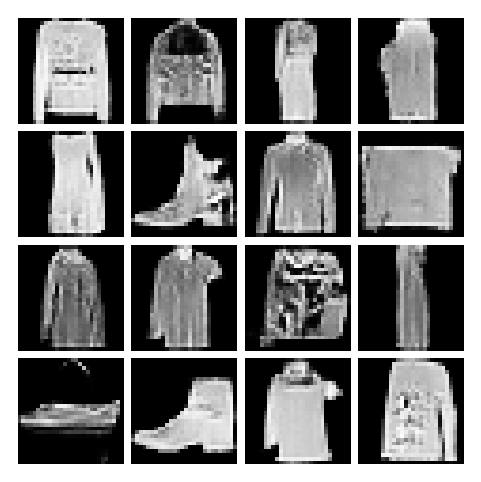

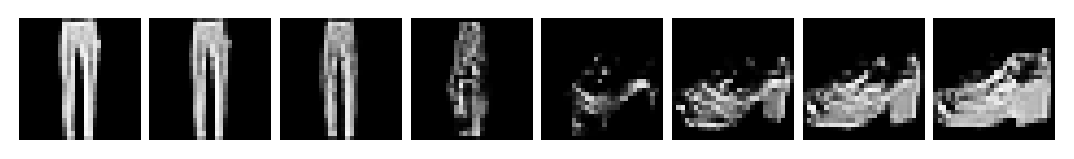

In [9]:
show_gan_samples(sn_G, device)
show_gan_interpolation(sn_G, device)


## Conditional GANs

The **conditional GAN** changes the task itself. Instead of asking the generator to model all Fashion MNIST images at once, the model is told which class should be generated. The label controls the broad semantic target, while the latent noise controls the remaining details.

This is the adversarial analogue of the conditional VAE idea. In both cases, conditioning separates *what should be specified* from *what should remain random*. The difference is the training signal: the conditional VAE uses an explicit conditional likelihood bound, while the conditional GAN uses a discriminator that checks both realism and label compatibility.

A **conditional GAN** models $p_{gt}(\boldsymbol{x}|\boldsymbol{y})$ rather than $p_{gt}(\boldsymbol{x})$. The generator receives both latent noise and a condition,

```{math}
\boldsymbol{x}_{fake}
=
G_\theta(\boldsymbol{z},\boldsymbol{y}),
```

and the discriminator receives both an image and the condition:

```{math}
D_\psi(\boldsymbol{x},\boldsymbol{y}).
```

The minimax objective becomes

```{math}
\min_G \max_D
\mathbb{E}_{(\boldsymbol{x},\boldsymbol{y})\sim p_{gt}}
[\log D(\boldsymbol{x},\boldsymbol{y})]
+
\mathbb{E}_{\boldsymbol{z}\sim p(\boldsymbol{z}),\boldsymbol{y}\sim p(\boldsymbol{y})}
[\log(1-D(G(\boldsymbol{z},\boldsymbol{y}),\boldsymbol{y}))].
```

The condition must influence both players. If it is given only to the generator, the discriminator cannot check whether a generated image matches the requested label. If it is given only to the discriminator, the generator does not know what it was asked to synthesize. In the implementation below, labels are embedded and concatenated with noise in the generator, while the discriminator receives a label-dependent image channel. This makes the compatibility test explicit.

```{figure} ../assets/images/cGAN.png
:width: 66%
:align: center

In cGAN, both the generator and the discriminator knows the conditioning vector.
```

The motivation is straightforward. In an **unconditional GAN**, the generator must spend capacity on deciding both what class to generate and how that class should look. In a **conditional GAN**, the class decision is supplied externally. The latent variable can then focus on residual variation within the class: shoe shape, sleeve width, bag contour, and other details. This is why class-conditional generation is often easier to inspect than unconditional generation. We can ask separately whether the requested class is respected and whether samples within that class remain diverse.

In [10]:
num_classes = 10


class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=128, base_channels=64, num_classes=10, label_dim=16):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, label_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + label_dim, base_channels * 4 * 7 * 7),
            nn.BatchNorm1d(base_channels * 4 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z, y):
        y_embed = self.label_embed(y)
        return self.net(torch.cat([z, y_embed], dim=1))


class ConditionalDiscriminator(nn.Module):
    def __init__(self, base_channels=64, num_classes=10, label_dim=16):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, 28 * 28)
        self.net = nn.Sequential(
            nn.Conv2d(2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(base_channels * 2 * 7 * 7, 1),
        )

    def forward(self, x, y):
        y_map = self.label_embed(y).view(-1, 1, 28, 28)
        return self.net(torch.cat([x, y_map], dim=1))


cG = ConditionalGenerator(latent_dim=latent_dim, base_channels=base_channels, num_classes=num_classes).to(device)
cD = ConditionalDiscriminator(base_channels=base_channels, num_classes=num_classes).to(device)

# Typical usage:
# labels = labels.to(device)
# z = torch.randn(labels.size(0), latent_dim, device=device)
# fake_images = cG(z, labels)
# real_logits = cD(real_images, labels)
# fake_logits = cD(fake_images.detach(), labels)


In [11]:
cG = ConditionalGenerator(latent_dim=latent_dim, base_channels=base_channels, num_classes=num_classes).to(device)
cD = ConditionalDiscriminator(base_channels=base_channels, num_classes=num_classes).to(device)
cgan_g_optimizer = torch.optim.Adam(cG.parameters(), lr=lr, betas=(0.5, 0.999))
cgan_d_optimizer = torch.optim.Adam(cD.parameters(), lr=lr, betas=(0.5, 0.999))
conditional_gan_epochs = 50
conditional_gan_history = {"d_loss": [], "g_loss": []}

for epoch in tqdm(range(conditional_gan_epochs), desc="cGAN epochs"):
    d_running = 0.0
    g_running = 0.0

    for real_images, labels in tqdm(train_loader, desc="cGAN train", leave=False):
        real_images = real_images.to(device)
        labels = labels.to(device)
        batch_n = real_images.size(0)

        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = cG(z, labels)

        cgan_d_optimizer.zero_grad()
        real_logits = cD(real_images, labels)
        fake_logits = cD(fake_images.detach(), labels)
        d_loss = discriminator_loss(real_logits, fake_logits)
        d_loss.backward()
        cgan_d_optimizer.step()

        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = cG(z, labels)

        cgan_g_optimizer.zero_grad()
        fake_logits = cD(fake_images, labels)
        g_loss = generator_loss(fake_logits)
        g_loss.backward()
        cgan_g_optimizer.step()

        d_running += d_loss.item()
        g_running += g_loss.item()

    d_epoch = d_running / len(train_loader)
    g_epoch = g_running / len(train_loader)
    conditional_gan_history["d_loss"].append(d_epoch)
    conditional_gan_history["g_loss"].append(g_epoch)

    print(
        f"Epoch {epoch + 1:02d} | cD loss: {d_epoch:.4f} | cG loss: {g_epoch:.4f}"
    )


cGAN epochs:   0%|          | 0/50 [00:00<?, ?it/s]

cGAN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | cD loss: 1.1817 | cG loss: 1.1359


cGAN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | cD loss: 1.1665 | cG loss: 1.1257


...

Epoch 48 | cD loss: 1.3795 | cG loss: 0.8264


cGAN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | cD loss: 1.3799 | cG loss: 0.8244


cGAN train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | cD loss: 1.3805 | cG loss: 0.8265


```{admonition} Conditional GAN diagnostic
:class: note

Rows test whether the condition is respected. Columns test whether the latent noise still produces diversity inside the requested condition.
```

The conditional discriminator now has a stricter job than the unconditional one. It must reject not only unrealistic images, but also **mismatched** image-label pairs. A generated boot with the label `T-shirt/top` should count as wrong even if it looks locally plausible as an image. This changes the meaning of the adversarial signal. The discriminator is no longer only learning a realism boundary. It is learning a joint compatibility test over $(\boldsymbol{x},\boldsymbol{y})$.

This is also where **conditional GANs** can fail. The generator may ignore the noise and produce one prototype per label, which gives correct classes but poor diversity. Or it may ignore the label and behave like an **unconditional GAN**, which gives diverse samples but poor control. The visual diagnostic therefore has two axes: class correctness across rows and diversity within each row.

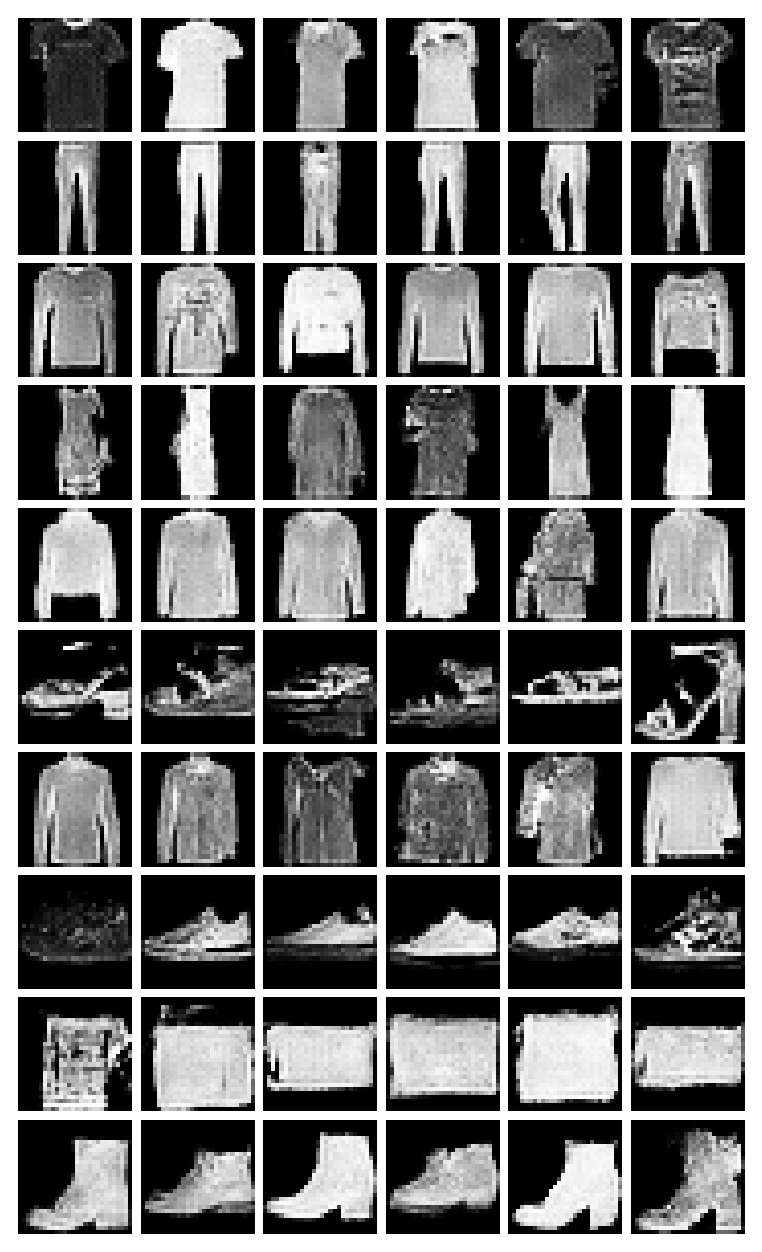

row 0: T-shirt/top
row 1: Trouser
row 2: Pullover
row 3: Dress
row 4: Coat
row 5: Sandal
row 6: Shirt
row 7: Sneaker
row 8: Bag
row 9: Ankle boot


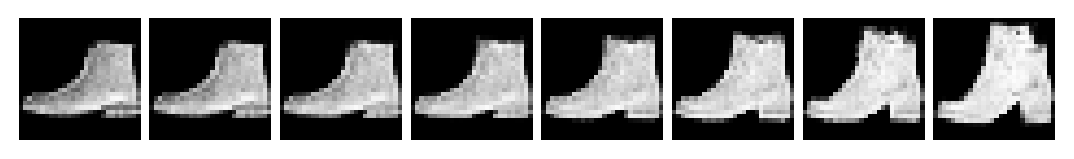

class-conditioned interpolation: Ankle boot


In [12]:
@torch.no_grad()
def show_cgan_class_samples(generator, class_names, device, n_per_class=6):
    generator.eval()
    rows = []
    for class_id, _ in enumerate(class_names):
        labels = torch.full((n_per_class,), class_id, device=device, dtype=torch.long)
        z = torch.randn(n_per_class, latent_dim, device=device)
        samples = generator(z, labels)
        samples = 0.5 * (samples + 1.0)
        rows.append(samples.cpu())

    image = utils.make_grid(torch.cat(rows, dim=0), nrow=n_per_class, pad_value=1.0)
    plt.figure(figsize=(1.6 * n_per_class, 1.6 * len(class_names)))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()

    for class_id, name in enumerate(class_names):
        print(f"row {class_id}: {name}")


@torch.no_grad()
def interpolate_cgan_with_fixed_class(generator, class_id, class_name, device, steps=8):
    generator.eval()
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * z0 + alphas * z1
    labels = torch.full((steps,), class_id, device=device, dtype=torch.long)
    samples = 0.5 * (generator(z, labels) + 1.0)
    image = utils.make_grid(samples.cpu(), nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()
    print(f"class-conditioned interpolation: {class_name}")


show_cgan_class_samples(cG, train_dataset.classes, device, n_per_class=6)
interpolate_cgan_with_fixed_class(cG, class_id=9, class_name=train_dataset.classes[9], device=device)


Here the expectation is **class-wise coherence** with **intra-class variety**. The `Pullover` row should mostly stay in the pullover family, but different columns should still vary in collar, sleeve width, texture, or silhouette. If every row looks nearly identical internally, then the conditioning may be working while diversity is failing. If rows look mixed across classes, then the label signal is not being used strongly enough.

The interpolation experiment checks the same idea from a different angle. Once the class is fixed, moving through **latent space** should change style and local structure while preserving category identity. If the interpolation quietly crosses semantic classes, then the generator is not really separating **condition information** from residual variation. If interpolation does almost nothing, then the generator may be ignoring the latent noise. Conditional generation should preserve the condition while still using the random input.

`WGAN-GP`, **spectral normalization**, and **conditional GANs** are the core mechanisms implemented here. Other important families such as `CycleGAN`, `StyleGAN`, and `BigGAN` become easier to read once these three levers are understood: change the discrepancy, constrain the critic, or provide structured conditioning.

## Shared FID/KID Comparison With Cached Real Features

The qualitative experiments above inspect each variant separately. **FID** and **KID** compare the generated distributions under a common metric pipeline. The helper below computes the real-image features once and reuses them for the fake-image passes of all three variants.

In [13]:
import copy
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)

@torch.no_grad()
def build_cached_real_metrics(real_loader, device, num_real=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(feature=2048, normalize=True, reset_real_features=False).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(feature=2048, subsets=10, subset_size=100, normalize=True, reset_real_features=False).to(device)
    seen = 0
    for real_images, _ in tqdm(real_loader, desc='real metric cache', leave=False):
        remaining = num_real - seen
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = prepare_for_inception_metrics(0.5 * (real_images + 1.0))
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen += real_images.size(0)
    return fid, kid

@torch.no_grad()
def evaluate_with_cached_real(sample_fn, base_fid, base_kid, num_fake=1000, metric_batch_size=64):
    fid = copy.deepcopy(base_fid)
    kid = copy.deepcopy(base_kid)
    generated = 0
    pbar = tqdm(total=num_fake, desc='fake metric pass', leave=False)
    while generated < num_fake:
        batch_n = min(metric_batch_size, num_fake - generated)
        fake_images = prepare_for_inception_metrics(sample_fn(batch_n))
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()
    kid_mean, kid_std = kid.compute()
    return {'fid': fid.compute().item(), 'kid_mean': kid_mean.item(), 'kid_std': kid_std.item()}

base_fid, base_kid = build_cached_real_metrics(train_loader, device)
wgan_scores = evaluate_with_cached_real(lambda n: 0.5 * (wgan_G(torch.randn(n, latent_dim, device=device)) + 1.0), base_fid, base_kid)
sn_scores = evaluate_with_cached_real(lambda n: 0.5 * (sn_G(torch.randn(n, latent_dim, device=device)) + 1.0), base_fid, base_kid)
cgan_scores = evaluate_with_cached_real(
    lambda n: 0.5 * (cG(torch.randn(n, latent_dim, device=device), torch.randint(0, num_classes, (n,), device=device)) + 1.0),
    base_fid, base_kid,
)
print({'wgan_gp': wgan_scores, 'sn_gan': sn_scores, 'cgan': cgan_scores})


c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metric cache:   0%|          | 0/469 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

{'wgan_gp': {'fid': 36.24203707127032, 'kid_mean': 0.008288717828691006, 'kid_std': 0.0019558744970709085}, 'sn_gan': {'fid': 37.695591837160805, 'kid_mean': 0.009904908947646618, 'kid_std': 0.003469672054052353}, 'cgan': {'fid': 44.52157573776128, 'kid_mean': 0.019974995404481888, 'kid_std': 0.003921906463801861}}


The three implemented variants target different weaknesses of the original adversarial formulation. `WGAN-GP` changes critic geometry and gives the generator a smoother transport-like signal. **Spectral normalization** controls the discriminator function class and reduces overly sharp feedback. **Conditional GANs** change the modeled distribution from $p_{gt}(\boldsymbol{x})$ to $p_{gt}(\boldsymbol{x}|\boldsymbol{y})$, making generation controllable. These are not unrelated tricks, but distinct interventions on the adversarial game.

## A Brief Outlook Beyond the Core Set

Many other GAN variants can be understood as combinations or extensions of the mechanisms already studied. `CycleGAN` extends conditional adversarial learning to unpaired image-to-image translation. Since paired examples are unavailable, the adversarial loss alone cannot determine the correct semantic mapping between two domains. The cycle-consistency loss adds the requirement that translating from domain A to domain B and back should approximately recover the original image.

`StyleGAN` changes the generator architecture rather than only the discriminator or loss. Its central idea is to control image synthesis through style-like latent modulation at multiple resolutions. This makes the generator's **latent space** more structured and gives much finer control over coarse shape, intermediate structure, and fine texture.

`BigGAN` shows what happens when class conditioning, stabilization, large batch training, and high-capacity architectures are combined at scale. It is historically important because it demonstrated very strong class-conditional image synthesis before diffusion models became dominant.

These models continue the same methodological pattern: identify a weakness of the basic adversarial game, then decide which part of the system should change. The objective can change, the critic can be constrained, the generator can be redesigned, or the conditioning information can be made richer.